# Electricity detector comparison inside STUDD

This notebook compares different drift detectors inside the STUDD mechanism on the Electricity dataset.

Unlike SEA, Electricity does not provide a known true drift point.

Following the evaluation approach of the STUDD paper, we use the first alarm produced by the strongly supervised signal detector (SS) as a reference drift indication.

For each STUDD detector, we compare:

- all STUDD alarms
- the STUDD alarm closest to the first SS alarm
- teacher accuracy around the first SS alarm
- teacher-student disagreement around the first SS alarm
- teacher accuracy around the closest STUDD alarm
- teacher-student disagreement around the closest STUDD alarm

In [13]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from capymoa.datasets import Electricity

from capymoa.drift.detectors import (
    STUDD,
    ADWIN,
    PageHinkley,
    HDDMAverage,
    HDDMWeighted,
    CUSUM,
)

from helpers import (
    configure_matplotlib,
    rolling_mean,
)

from studd_utils import (
    make_teacher,
    make_student,
    collect_instances,
)

configure_matplotlib()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Experimental parameters

The teacher is trained on the first `W` labeled samples.

During monitoring, the teacher remains fixed and the student learns to mimic the teacher.

The supervised signal detector (SS) monitors the teacher prediction error using labels.

The first SS alarm is used as the reference drift indication.

In [14]:
SEED = 42

W = 2000
N_STREAM = 45312

N_TREES = 100
TEACHER_TYPE = "rf"
STUDENT_TYPE = "ht"

LOCAL_WINDOW = 100
ROLLING_WINDOW = 200

## Detectors

We compare five detectors inside STUDD.

Page-Hinkley is configured with `delta=0.001`.

In [15]:
DETECTORS = {
    "ADWIN": lambda: ADWIN(),
    "PageHinkley": lambda: PageHinkley(delta=0.001),
    "HDDMAverage": lambda: HDDMAverage(test_type="One-sided"),
    "HDDMWeighted": lambda: HDDMWeighted(test_type="One-sided"),
    "CUSUM": lambda: CUSUM(),
}

## Compute SS reference alarms

Before comparing STUDD detectors, we compute the supervised signal (SS) alarms.

The SS detector monitors the teacher error:

`error = 1 - teacher_correct`

In [16]:
electricity_stream = Electricity()
schema = electricity_stream.get_schema()

teacher = make_teacher(
    schema=schema,
    teacher_type=TEACHER_TYPE,
    seed=SEED,
    n_trees=N_TREES,
)

reference_instances = collect_instances(
    electricity_stream,
    W,
)

for inst in reference_instances:
    teacher.train(inst)

ss_detector = PageHinkley(
    delta=0.001,
)

ss_records = []
ss_drift_points = []

processed = W

while electricity_stream.has_more_instances() and processed < N_STREAM:

    inst = electricity_stream.next_instance()

    y_true = inst.y_index
    y_teacher = teacher.predict(inst)

    if y_teacher is None:
        processed += 1
        continue

    teacher_correct = int(y_teacher == y_true)
    teacher_error = 1 - teacher_correct

    ss_detector.add_element(teacher_error)

    ss_detected_change = ss_detector.detected_change()

    if ss_detected_change:
        ss_drift_points.append(int(processed))

    ss_records.append({
        "t": int(processed),
        "teacher_correct": teacher_correct,
        "teacher_error": teacher_error,
        "ss_alarm": ss_detected_change,
    })

    processed += 1

ss_results = pd.DataFrame(ss_records)

reference_drift = int(ss_drift_points[0])

print("SS alarms:", ss_drift_points)
print("Reference drift point:", reference_drift)

SS alarms: [6334, 6957, 7630, 14616, 19947, 27198, 29687, 32380]
Reference drift point: 6334


## Data visualization

Before evaluating the STUDD detectors, we check the Electricity stream to determine whether the feature distribution changes over time.

The visualization includes:

- a PCA projection of the stream
- rolling means of all features

In [17]:
electricity_vis_stream = Electricity()

X_vis = []

N_VIS = min(20000, N_STREAM)

while electricity_vis_stream.has_more_instances() and len(X_vis) < N_VIS:
    inst = electricity_vis_stream.next_instance()
    X_vis.append(inst.x)

X_vis = np.asarray(X_vis, dtype=float)

print("Visualization sample shape:", X_vis.shape)

Visualization sample shape: (20000, 8)


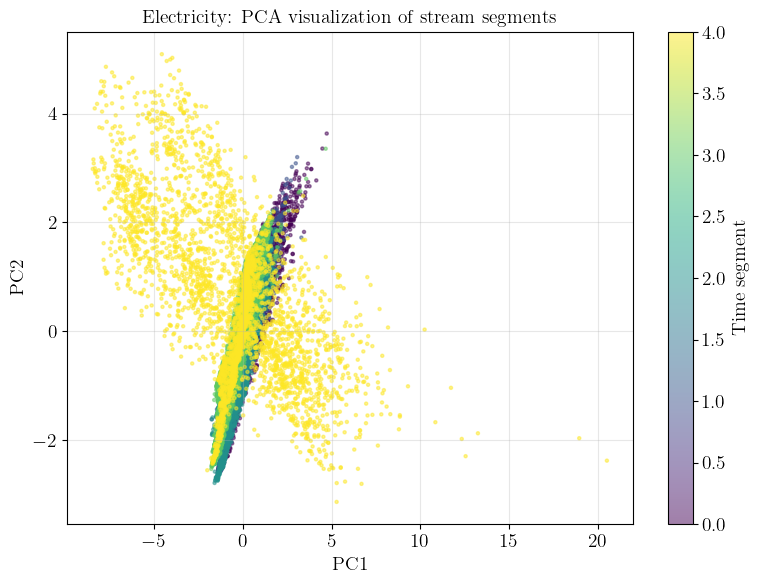

Explained variance ratio: [0.30930983 0.17305164]
Total explained variance: 0.4823614695689874


In [18]:
X_scaled = StandardScaler().fit_transform(X_vis)

pca = PCA(
    n_components=2,
    random_state=SEED,
)

X_pca = pca.fit_transform(X_scaled)

segment_size = len(X_vis) // 5

segments = np.minimum(
    np.arange(len(X_vis)) // segment_size,
    4,
)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=segments,
    s=5,
    alpha=0.5,
)

plt.title("Electricity: PCA visualization of stream segments")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Time segment")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

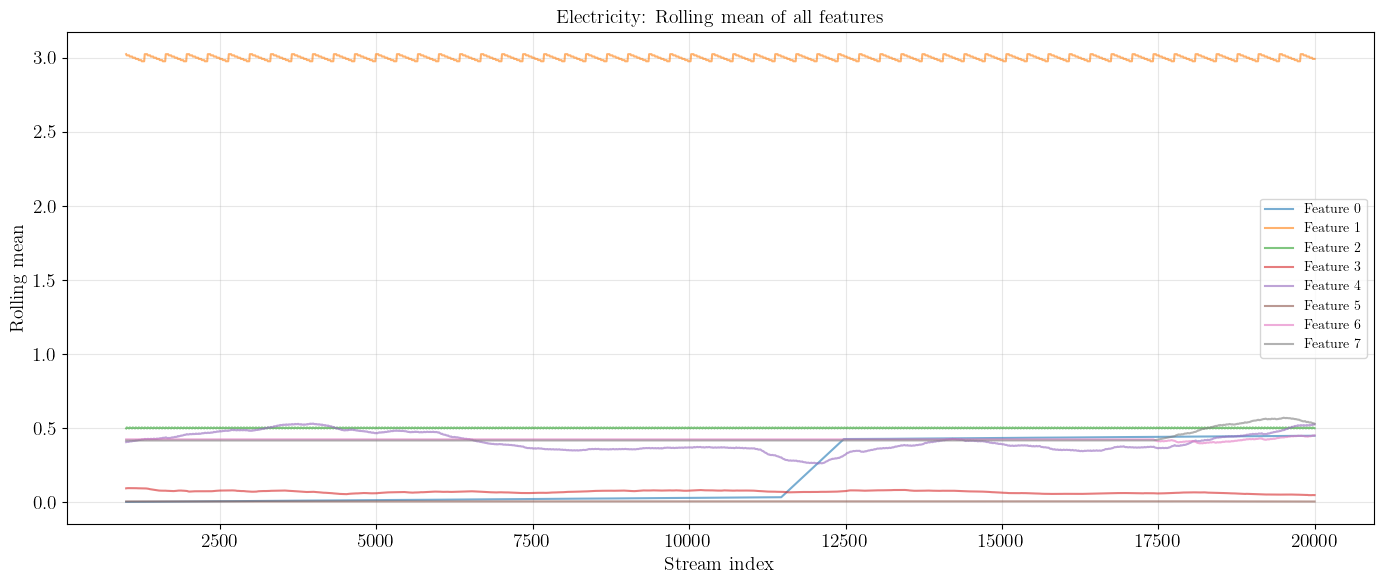

In [19]:
FEATURE_ROLLING_WINDOW = 1000

X_df = pd.DataFrame(X_vis)

rolling_feature_means = (
    X_df
    .rolling(FEATURE_ROLLING_WINDOW)
    .mean()
)

plt.figure(figsize=(14, 6))

for feature in rolling_feature_means.columns:
    plt.plot(
        rolling_feature_means.index,
        rolling_feature_means[feature],
        linewidth=1.5,
        alpha=0.6,
        label=f"Feature {feature}",
    )

plt.title("Electricity: Rolling mean of all features")
plt.xlabel("Stream index")
plt.ylabel("Rolling mean")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Run STUDD with each detector

Each STUDD detector is evaluated independently.

For each detector, we recreate the Electricity stream, train the same teacher model, initialize the same student model and run STUDD.

The only changing component is the drift detector used inside STUDD.

In [20]:
comparison_runs = {}

for detector_name, detector_factory in DETECTORS.items():

    print(f"Running {detector_name}...")

    electricity_stream = Electricity()
    schema = electricity_stream.get_schema()

    teacher = make_teacher(
    schema=schema,
    teacher_type=TEACHER_TYPE,
    seed=SEED,
    n_trees=N_TREES,
    )

    reference_instances = collect_instances(
        electricity_stream,
        W,
    )

    for inst in reference_instances:
        teacher.train(inst)

    student = make_student(
        schema=schema,
        student_type=STUDENT_TYPE,
        seed=SEED,
        n_trees=N_TREES,
    )

    studd = STUDD(
        student=student,
        min_n_instances=W,
        detector=detector_factory(),
    )

    records = []
    studd_drift_points = []

    processed = W

    while electricity_stream.has_more_instances() and processed < N_STREAM:

        inst = electricity_stream.next_instance()

        y_true = inst.y_index
        y_teacher = teacher.predict(inst)

        if y_teacher is None:
            processed += 1
            continue

        teacher_correct = int(y_teacher == y_true)

        studd.add_element(
            inst,
            y_teacher,
        )

        detected_change = studd.detected_change()

        if detected_change:
            studd_drift_points.append(
                int(processed)
            )

        records.append({
            "t": int(processed),
            "teacher_correct": teacher_correct,
            "drift_alarm": detected_change,
        })

        processed += 1

    results = pd.DataFrame(records)

    agreement = np.array(
        studd.data,
        dtype=float,
    )

    disagreement = 1.0 - agreement

    agreement_idx = (
        np.arange(len(agreement))
        + studd.min_n_instances
    )

    first_alarm = (
        studd_drift_points[0]
        if studd_drift_points
        else None
    )

    closest_alarm = (
        min(
            studd_drift_points,
            key=lambda alarm: abs(alarm - reference_drift),
        )
        if studd_drift_points
        else None
    )

    closest_alarm_delay = (
        closest_alarm - reference_drift
        if closest_alarm is not None
        else None
    )

    # Metrics around the first SS alarm

    reference_before_disagreement = disagreement[
        (agreement_idx >= reference_drift - LOCAL_WINDOW)
        &
        (agreement_idx < reference_drift)
    ]

    reference_after_disagreement = disagreement[
        (agreement_idx >= reference_drift)
        &
        (agreement_idx < reference_drift + LOCAL_WINDOW)
    ]

    reference_before_accuracy = results[
        (results["t"] >= reference_drift - LOCAL_WINDOW)
        &
        (results["t"] < reference_drift)
    ]["teacher_correct"]

    reference_after_accuracy = results[
        (results["t"] >= reference_drift)
        &
        (results["t"] < reference_drift + LOCAL_WINDOW)
    ]["teacher_correct"]

    # Metrics around the closest STUDD alarm

    if closest_alarm is not None:

        closest_alarm_before_disagreement = disagreement[
            (agreement_idx >= closest_alarm - LOCAL_WINDOW)
            &
            (agreement_idx < closest_alarm)
        ]

        closest_alarm_after_disagreement = disagreement[
            (agreement_idx >= closest_alarm)
            &
            (agreement_idx < closest_alarm + LOCAL_WINDOW)
        ]

        closest_alarm_before_accuracy = results[
            (results["t"] >= closest_alarm - LOCAL_WINDOW)
            &
            (results["t"] < closest_alarm)
        ]["teacher_correct"]

        closest_alarm_after_accuracy = results[
            (results["t"] >= closest_alarm)
            &
            (results["t"] < closest_alarm + LOCAL_WINDOW)
        ]["teacher_correct"]

    else:

        closest_alarm_before_disagreement = np.array([])
        closest_alarm_after_disagreement = np.array([])

        closest_alarm_before_accuracy = pd.Series(dtype=float)
        closest_alarm_after_accuracy = pd.Series(dtype=float)

    summary = {
        "detector": detector_name,

        "num_alarms": len(studd_drift_points),
        "alarms": studd_drift_points,

        "closest_alarm": closest_alarm,
        "closest_alarm_delay_from_ss": closest_alarm_delay,

        "reference_accuracy_delta": (
            reference_after_accuracy.mean()
            - reference_before_accuracy.mean()
        ),

        "reference_disagreement_delta": (
            reference_after_disagreement.mean()
            - reference_before_disagreement.mean()
        ),

        "closest_alarm_accuracy_delta": (
            closest_alarm_after_accuracy.mean()
            - closest_alarm_before_accuracy.mean()
        ),

        "closest_alarm_disagreement_delta": (
            closest_alarm_after_disagreement.mean()
            - closest_alarm_before_disagreement.mean()
        ),
    }

    comparison_runs[detector_name] = {
        "summary": summary,
        "results": results,
        "agreement_idx": agreement_idx,
        "agreement": agreement,
        "disagreement": disagreement,
        "studd_drift_points": studd_drift_points,
    }

print("Done.")

Running ADWIN...


Running PageHinkley...
Running HDDMAverage...
Running HDDMWeighted...
Running CUSUM...
Done.


## Summary table

This table contains all metrics collected for each STUDD detector.

The main reference point is the first SS alarm.

For Electricity, a useful STUDD detector should ideally:

- produce alarms reasonably close to the first SS alarm
- avoid excessive false alarms
- show meaningful disagreement changes around either the SS reference point or the closest STUDD alarm.

In [21]:
summary_df = pd.DataFrame([
    run["summary"]
    for run in comparison_runs.values()
])

summary_df = (
    summary_df
    .sort_values(
        "closest_alarm_delay_from_ss",
        key=lambda s: s.abs(),
        na_position="last",
    )
    .reset_index(drop=True)
)

summary_df

,detector,num_alarms,alarms,closest_alarm,closest_alarm_delay_from_ss,reference_accuracy_delta,reference_disagreement_delta,closest_alarm_accuracy_delta,closest_alarm_disagreement_delta
0,HDDMWeighted,11,"[9630, 11814, 12242, 13042, 17827, 27458, 3967...",9630,3296,0.167959,0.03,0.086495,-0.24
1,ADWIN,16,"[14020, 14277, 14405, 14501, 14535, 15241, 157...",14020,7686,0.167959,0.03,0.264040,0.05
2,CUSUM,2,"[14526, 22634]",14526,8192,0.167959,0.03,-0.112048,0.02
3,HDDMAverage,1,[14882],14882,8548,0.167959,0.03,-0.200000,0.02
4,PageHinkley,2,"[15590, 30104]",15590,9256,0.167959,0.03,0.134747,-0.23


## Typical drift detection metrics

This section computes classic drift detection metrics using the first SS alarm as the reference drift point.

Following the STUDD paper, alarms occurring more than `W` observations before the first SS alarm are considered false alarms.

Alarms occurring from `first SS alarm - W` onward are considered true drift alarms.

If a detector has no true drift alarm, it is considered to have missed the drift.

These metrics are computed per dataset and per detector.

In [22]:
DATASET_NAME = "Electricity"  

if len(ss_drift_points) == 0:
    raise ValueError(
        "SS did not trigger any alarm. "
        "This dataset cannot be used for SS-reference detection metrics."
    )

detection_metric_rows = []

valid_detection_start = reference_drift - W

for detector_name, run in comparison_runs.items():

    alarms = run["studd_drift_points"]

    false_alarms = [
        alarm
        for alarm in alarms
        if alarm < valid_detection_start
    ]

    true_drift_alarms = [
        alarm
        for alarm in alarms
        if alarm >= valid_detection_start
    ]

    if len(true_drift_alarms) == 0:

        missed_detection = 1
        first_true_detection = np.nan
        signed_detection_delay = np.nan
        detection_delay_for_mtd = np.nan
        normalized_detection_delay = np.nan

    else:

        missed_detection = 0

        # First alarm that qualifies as a true detection
        first_true_detection = int(min(true_drift_alarms))

        # Signed delay:
        # negative = detector alarmed before SS
        # positive = detector alarmed after SS
        signed_detection_delay = first_true_detection - reference_drift

        # For MTD, early detections are not penalized
        detection_delay_for_mtd = max(0, signed_detection_delay)

        normalized_detection_delay = (
            detection_delay_for_mtd / N_STREAM
        )

    has_false_alarm = int(len(false_alarms) > 0)

    if len(false_alarms) >= 2:

        false_alarm_intervals = np.diff(false_alarms)

        mean_time_between_false_alarms = float(
            np.mean(false_alarm_intervals)
        )

        normalized_mtfa = (
            mean_time_between_false_alarms / N_STREAM
        )

    else:

        mean_time_between_false_alarms = np.nan
        normalized_mtfa = np.nan

    detection_metric_rows.append({
        "dataset": DATASET_NAME,
        "detector": detector_name,

        "N_STREAM": N_STREAM,
        "W": W,
        "reference_drift": reference_drift,
        "valid_detection_start": valid_detection_start,

        "alarms": alarms,
        "num_alarms": len(alarms),

        "false_alarms": false_alarms,
        "num_false_alarms": len(false_alarms),
        "has_false_alarm": has_false_alarm,

        "true_drift_alarms": true_drift_alarms,
        "missed_detection": missed_detection,

        "first_true_detection": first_true_detection,
        "signed_detection_delay": signed_detection_delay,
        "detection_delay_for_mtd": detection_delay_for_mtd,
        "normalized_detection_delay": normalized_detection_delay,

        "mean_time_between_false_alarms": mean_time_between_false_alarms,
        "normalized_mtfa": normalized_mtfa,
    })

detection_metrics_df = pd.DataFrame(detection_metric_rows)

detection_metrics_df

,dataset,detector,N_STREAM,W,reference_drift,valid_detection_start,alarms,num_alarms,false_alarms,num_false_alarms,has_false_alarm,true_drift_alarms,missed_detection,first_true_detection,signed_detection_delay,detection_delay_for_mtd,normalized_detection_delay,mean_time_between_false_alarms,normalized_mtfa
0,Electricity,ADWIN,45312,2000,6334,4334,"[14020, 14277, 14405, 14501, 14535, 15241, 157...",16,[],0,0,"[14020, 14277, 14405, 14501, 14535, 15241, 157...",0,14020,7686,7686,0.169624,NaN,NaN
1,Electricity,PageHinkley,45312,2000,6334,4334,"[15590, 30104]",2,[],0,0,"[15590, 30104]",0,15590,9256,9256,0.204273,NaN,NaN
2,Electricity,HDDMAverage,45312,2000,6334,4334,[14882],1,[],0,0,[14882],0,14882,8548,8548,0.188648,NaN,NaN
3,Electricity,HDDMWeighted,45312,2000,6334,4334,"[9630, 11814, 12242, 13042, 17827, 27458, 3967...",11,[],0,0,"[9630, 11814, 12242, 13042, 17827, 27458, 3967...",0,9630,3296,3296,0.072740,NaN,NaN
4,Electricity,CUSUM,45312,2000,6334,4334,"[14526, 22634]",2,[],0,0,"[14526, 22634]",0,14526,8192,8192,0.180791,NaN,NaN


In [23]:
compact_detection_metrics_df = detection_metrics_df[
    [
        "dataset",
        "detector",
        "missed_detection",
        "has_false_alarm",
        "normalized_detection_delay",
        "normalized_mtfa",
        "num_alarms",
        "num_false_alarms",
    ]
].copy()

compact_detection_metrics_df

,dataset,detector,missed_detection,has_false_alarm,normalized_detection_delay,normalized_mtfa,num_alarms,num_false_alarms
0,Electricity,ADWIN,0,0,0.169624,NaN,16,0
1,Electricity,PageHinkley,0,0,0.204273,NaN,2,0
2,Electricity,HDDMAverage,0,0,0.188648,NaN,1,0
3,Electricity,HDDMWeighted,0,0,0.072740,NaN,11,0
4,Electricity,CUSUM,0,0,0.180791,NaN,2,0


In [24]:
compact_detection_metrics_df.to_dict("records")

[{'dataset': 'Electricity',
  'detector': 'ADWIN',
  'missed_detection': 0,
  'has_false_alarm': 0,
  'normalized_detection_delay': 0.1696239406779661,
  'normalized_mtfa': nan,
  'num_alarms': 16,
  'num_false_alarms': 0},
 {'dataset': 'Electricity',
  'detector': 'PageHinkley',
  'missed_detection': 0,
  'has_false_alarm': 0,
  'normalized_detection_delay': 0.2042725988700565,
  'normalized_mtfa': nan,
  'num_alarms': 2,
  'num_false_alarms': 0},
 {'dataset': 'Electricity',
  'detector': 'HDDMAverage',
  'missed_detection': 0,
  'has_false_alarm': 0,
  'normalized_detection_delay': 0.1886475988700565,
  'normalized_mtfa': nan,
  'num_alarms': 1,
  'num_false_alarms': 0},
 {'dataset': 'Electricity',
  'detector': 'HDDMWeighted',
  'missed_detection': 0,
  'has_false_alarm': 0,
  'normalized_detection_delay': 0.07274011299435028,
  'normalized_mtfa': nan,
  'num_alarms': 11,
  'num_false_alarms': 0},
 {'dataset': 'Electricity',
  'detector': 'CUSUM',
  'missed_detection': 0,
  'has_fal

## Rolling teacher accuracy

The following plots show the rolling teacher accuracy for each detector run.

The first SS alarm is shown as a purple dashed line.

STUDD alarms are shown as red dotted lines.

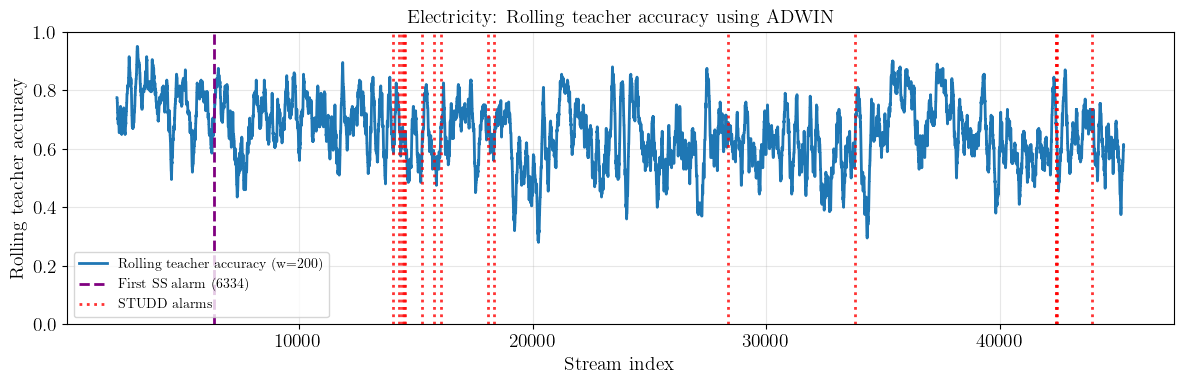

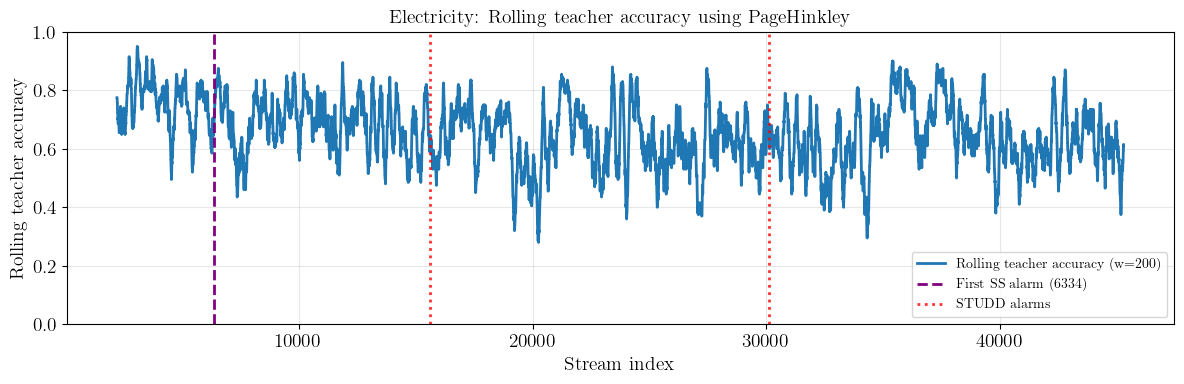

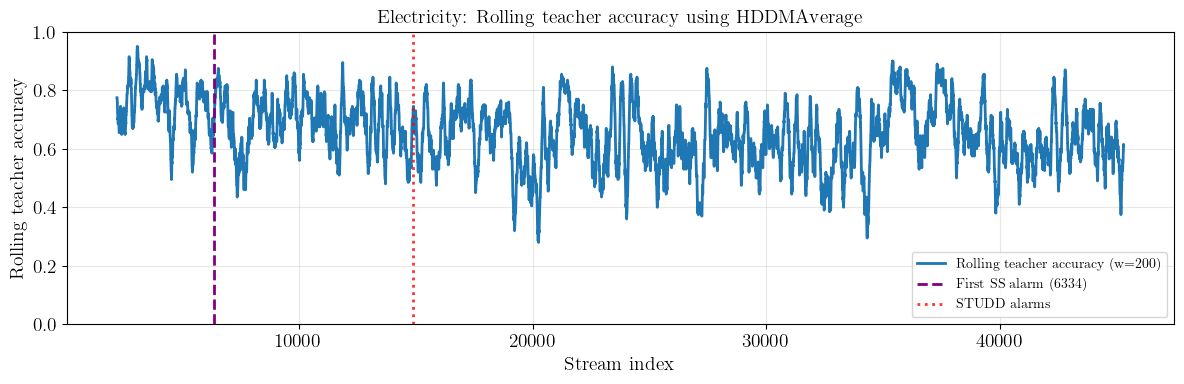

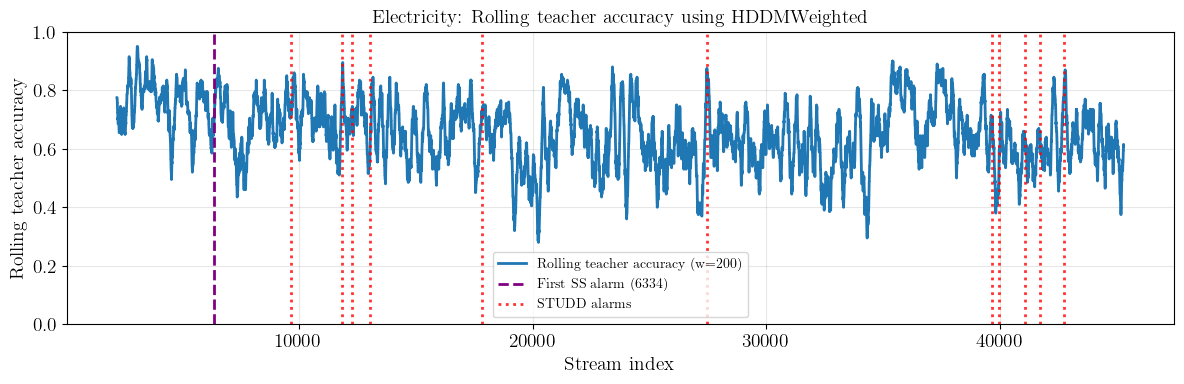

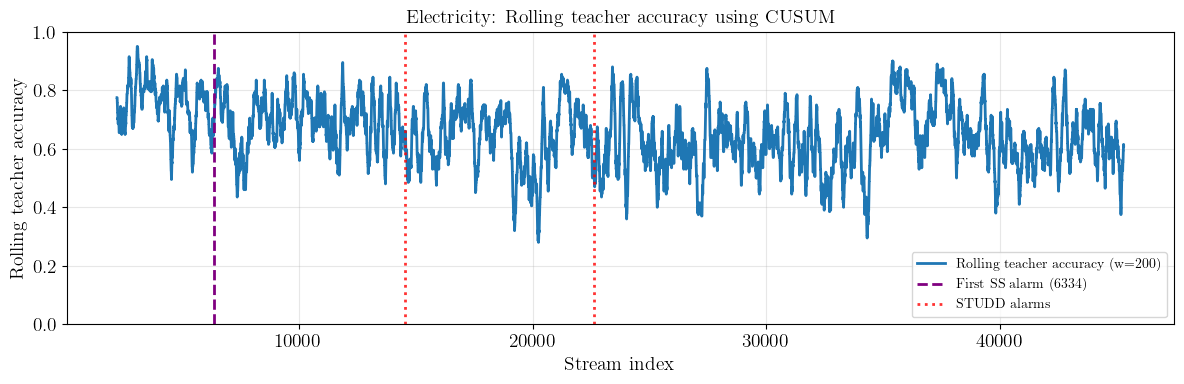

In [25]:
for detector_name, run in comparison_runs.items():

    results = run["results"]
    alarms = run["studd_drift_points"]

    rolling_accuracy, _ = rolling_mean(
        results["teacher_correct"].to_numpy(dtype=float),
        ROLLING_WINDOW,
    )

    rolling_t = results["t"].to_numpy()[
        ROLLING_WINDOW - 1:
    ]

    plt.figure(figsize=(12, 4))

    plt.plot(
        rolling_t,
        rolling_accuracy,
        linewidth=2,
        label=f"Rolling teacher accuracy (w={ROLLING_WINDOW})",
    )

    plt.axvline(
        reference_drift,
        color="purple",
        linestyle="--",
        linewidth=2,
        label=f"First SS alarm ({reference_drift})",
    )

    for i, alarm in enumerate(alarms):
        plt.axvline(
            alarm,
            color="red",
            linestyle=":",
            linewidth=2,
            alpha=0.8,
            label="STUDD alarms" if i == 0 else None,
        )

    plt.title(f"Electricity: Rolling teacher accuracy using {detector_name}")
    plt.xlabel("Stream index")
    plt.ylabel("Rolling teacher accuracy")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Rolling teacher-student disagreement

The following plots show the rolling teacher-student disagreement for each detector.

This is the signal monitored by STUDD.

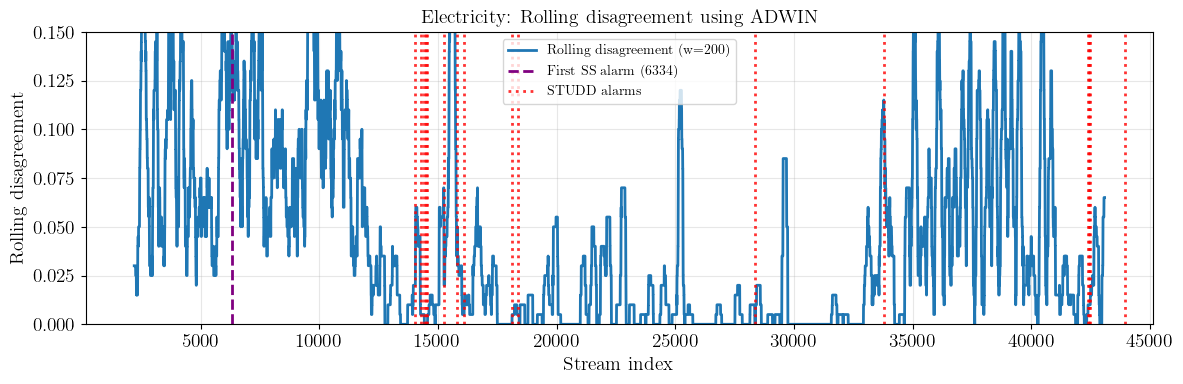

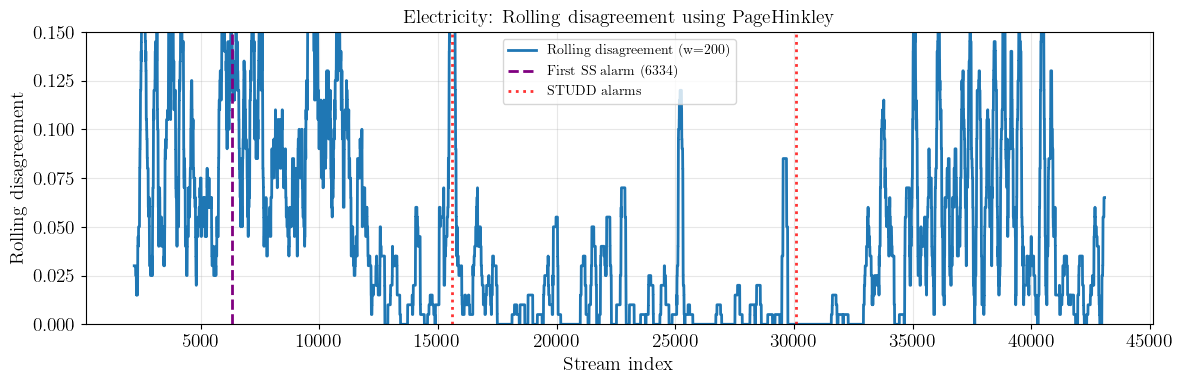

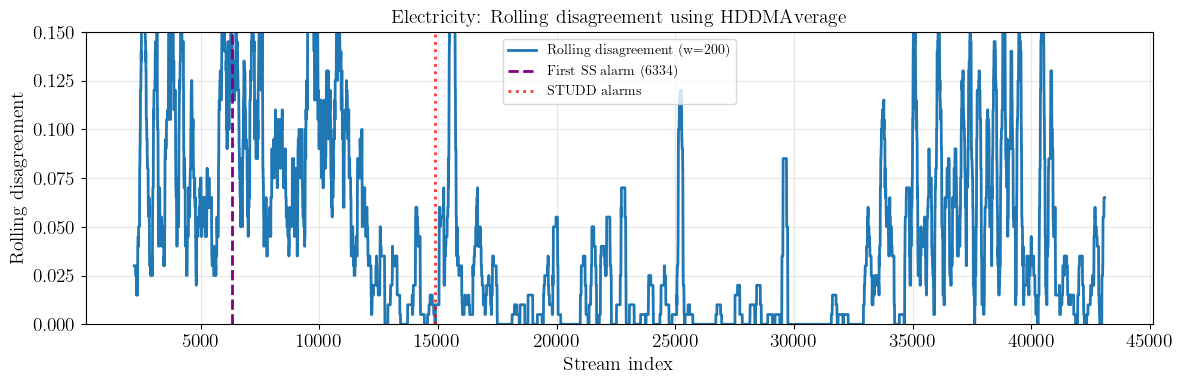

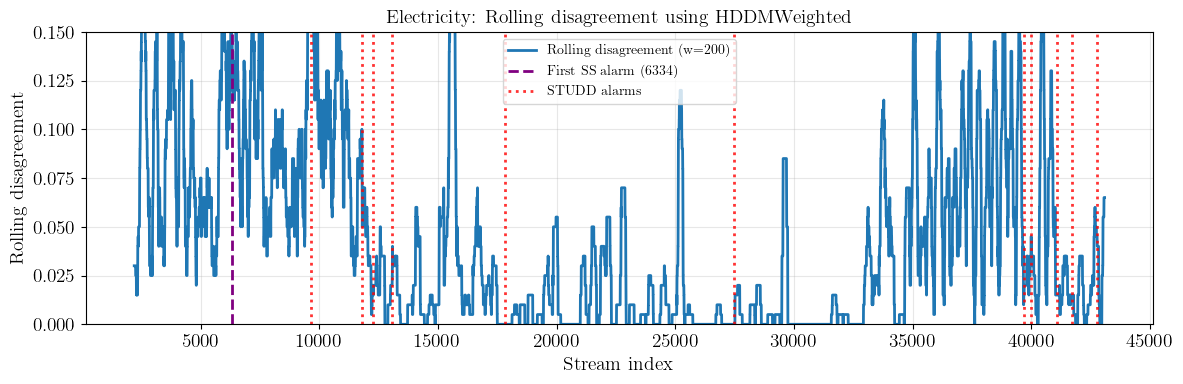

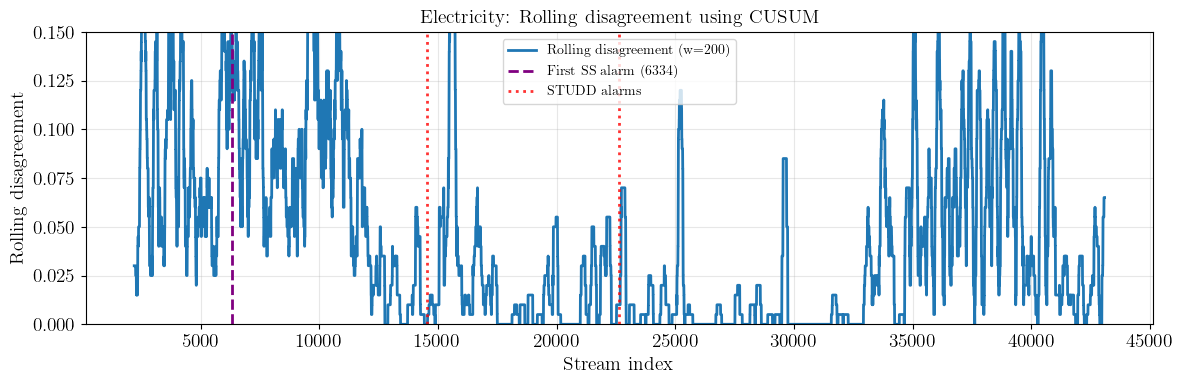

In [26]:
for detector_name, run in comparison_runs.items():

    agreement_idx = run["agreement_idx"]
    disagreement = run["disagreement"]
    alarms = run["studd_drift_points"]

    rolling_disagreement, _ = rolling_mean(
        disagreement,
        ROLLING_WINDOW,
    )

    rolling_t = agreement_idx[
        ROLLING_WINDOW - 1:
    ]

    plt.figure(figsize=(12, 4))

    plt.plot(
        rolling_t,
        rolling_disagreement,
        linewidth=2,
        label=f"Rolling disagreement (w={ROLLING_WINDOW})",
    )

    plt.axvline(
        reference_drift,
        color="purple",
        linestyle="--",
        linewidth=2,
        label=f"First SS alarm ({reference_drift})",
    )

    for i, alarm in enumerate(alarms):
        plt.axvline(
            alarm,
            color="red",
            linestyle=":",
            linewidth=2,
            alpha=0.8,
            label="STUDD alarms" if i == 0 else None,
        )

    plt.title(f"Electricity: Rolling disagreement using {detector_name}")
    plt.xlabel("Stream index")
    plt.ylabel("Rolling disagreement")
    plt.ylim(0, 0.15)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Detector comparison summary

This notebook compares the effect of changing the detector inside STUDD on the Electricity dataset.

Since Electricity does not provide a true drift point, the first SS alarm is used as a reference drift indication.

The key quantities are:

- closest alarm distance from ss : how close the STUDD detector came to the SS reference alarm
- false alarms : whether STUDD raised false alarms before or after the supervised reference point
- number of alarms : whether the detector is too sensitive
- reference disagreement delta : whether disagreement changes around the first SS alarm
- closest alarm disagreement delta : whether disagreement changes around the closest STUDD alarm